### quick notebook for testing new skull method implementation
(to be deleted)

In [1]:
from pathlib import Path
import os
import numpy as np

from dotenv import load_dotenv
from insilicoICH.ground_truth_definition.phantoms import load_phantom

nihpd_ages = [6.5, 9.0, 10.5, 11.5, 12.0, 15.75]

load_dotenv()
if 'PHANTOM_DIRECTORY' in os.environ:
    phantom_dir = Path(os.environ['PHANTOM_DIRECTORY'])
else:
    print('''
Please `export PHANTOM_DIRECTORY=/path/to/phantoms` or add your `.env`
file with PHANTOM_DIRECTORY=/path/to/phantoms
''')
    phantom_dir = Path(__file__).parent.absolute()

nihpd_dir = phantom_dir / 'NIHPD_Head_Phantom'
mida_dir = phantom_dir / 'MIDA_Head_Phantom'

print('loading phantoms')
phantom_old = load_phantom(nihpd_ages[2], skull_seg_method='old')
phantom_otsu = load_phantom(nihpd_ages[2], skull_seg_method='otsu')
phantom_pseudoct = load_phantom(nihpd_ages[2], skull_seg_method='pseudoct')

loading phantoms
old
otsu
using otsu method
using otsu method
pseudoct
using pseudoct method
using pseudoct method


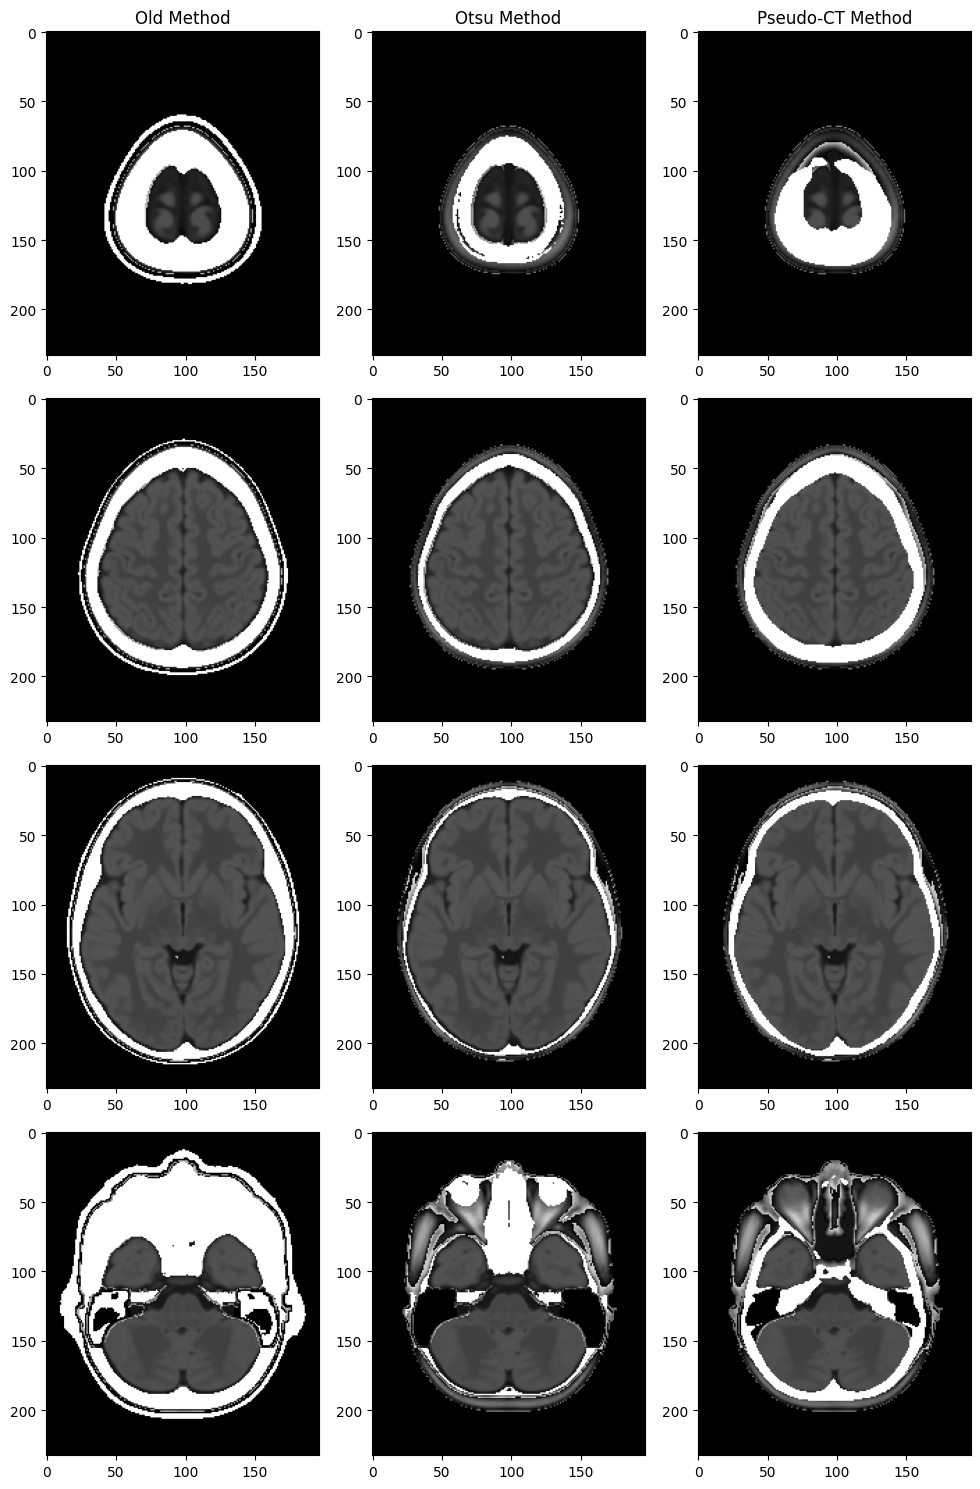

In [2]:
import matplotlib.pyplot as plt

fig, axs= plt.subplots(4, 3, figsize=(10,15))
axs[0, 0].set_title('Old Method')
axs[0, 0].imshow(phantom_old._phantom[36, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 0].imshow(phantom_old._phantom[60, :, :], cmap='gray', vmin=0, vmax=120)
axs[2, 0].imshow(phantom_old._phantom[120, :, :], cmap='gray', vmin=0, vmax=120)
axs[3, 0].imshow(phantom_old._phantom[160, :, :], cmap='gray', vmin=0, vmax=120)

axs[0, 1].set_title('Otsu Method')
axs[0, 1].imshow(phantom_otsu._phantom[36, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 1].imshow(phantom_otsu._phantom[60, :, :], cmap='gray', vmin=0, vmax=120)
axs[2, 1].imshow(phantom_otsu._phantom[120, :, :], cmap='gray', vmin=0, vmax=120)
axs[3, 1].imshow(phantom_otsu._phantom[160, :, :], cmap='gray', vmin=0, vmax=120)

axs[0, 2].set_title('Pseudo-CT Method')
axs[0, 2].imshow(phantom_pseudoct._phantom[36, :, :], cmap='gray', vmin=0, vmax=120)
axs[1, 2].imshow(phantom_pseudoct._phantom[60, :, :], cmap='gray', vmin=0, vmax=120)
axs[2, 2].imshow(phantom_pseudoct._phantom[120, :, :], cmap='gray', vmin=0, vmax=120)
axs[3, 2].imshow(phantom_pseudoct._phantom[160, :, :], cmap='gray', vmin=0, vmax=120)
plt.tight_layout()
plt.show()

In [3]:
import skimage as ski

test_mask = phantom.skull

boundary = ski.segmentation.find_boundaries(test_mask, mode='outer', background=0)

#new_boundary = ski.segmentation.flood(boundary, (0, 0, 0))

fig, axs = plt.subplots(1, 3, figsize=(10,5))
axs[0].imshow(test_mask[120, :, :], cmap='gray')
axs[1].imshow(boundary[120, :, :], cmap='gray')
axs[2].imshow(new_boundary[120, :, :], cmap='gray')
plt.show()

NameError: name 'phantom' is not defined